# Generating TOA Radiances with OSOAA for Atmospheric Correction

This notebook uses the OSOAA (Ocean Successive Orders with Atmosphere - Advanced) radiative transfer code to generate simulated top-of-atmosphere (TOA) radiance values. These synthetic observations can then be used to test and validate the `correct_atmosphere` package's ability to recover water-leaving radiances.

## Overview

OSOAA is a vector radiative transfer model for coupled atmosphere-ocean systems that:
- Computes full Stokes vector (I, Q, U, V) radiances
- Uses successive orders of scattering method
- Includes Rayleigh scattering, aerosols, ocean surface, and hydrosols

### Workflow

1. Configure OSOAA with realistic atmospheric and oceanic parameters
2. Run simulations at ocean color wavelengths (matching MODIS/VIIRS bands)
3. Extract TOA radiances at satellite viewing geometries
4. (Optionally) Apply the `correct_atmosphere` algorithm to recover water-leaving radiances
5. Compare recovered Lw with OSOAA's "true" water-leaving radiance

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# correct_atmosphere imports
from correct_atmosphere.correction import GeometryAngles, AncillaryData
from correct_atmosphere.osoaa import (
    OSOAASimulation,
    SimulationScenario,
    OSOAADataset,
    scale_aot_angstrom,
    create_dataset,
    save_dataset,
    load_dataset,
    run_toa_simulations,
    run_subsurface_simulations,
    extract_radiances,
)

# Configure OSOAA paths
# Adjust this path to your OSOAA installation
OSOAA_ROOT = Path(os.environ.get(
    'OSOAA_ROOT', 
    '/home/xavier/Oceanography/RadiativeTransferCode-OSOAA'
)).resolve()

OSOAA_EXE = OSOAA_ROOT / 'exe' / 'OSOAA_MAIN.exe'

print(f"OSOAA Root: {OSOAA_ROOT}")
print(f"Executable exists: {OSOAA_EXE.exists()}")

OSOAA Root: /home/xavier/Oceanography/RadiativeTransferCode-OSOAA
Executable exists: True


## 2. OSOAA Simulation Class

The `OSOAASimulation` class (imported from `correct_atmosphere.osoaa`) wraps the OSOAA Fortran executable and provides methods to:
- Configure simulations with appropriate parameters
- Run both TOA and subsurface simulations
- Parse standard (`LUM_vsVZA`) and advanced (`LUM_Advanced_Up`) output files

**Important OSOAA conventions:**
- Wavelength is in **micrometers** (not nanometers)
- Imaginary refractive indices are **negative** (absorption convention)
- Output radiances are normalized: $\pi L / E_{sun}$
- OSOAA does **not** include gas absorption; only scattering is modelled

In [2]:
# Initialize simulation
sim = OSOAASimulation(OSOAA_ROOT)

print(f"OSOAASimulation ready")
print(f"  Executable: {sim.exe_path}")
print(f"  Working dir: {sim.work_dir}")

Working directory: /tmp/osoaa_toa_tpz6ofnu
OSOAASimulation ready
  Executable: /home/xavier/Oceanography/RadiativeTransferCode-OSOAA/exe/OSOAA_MAIN.exe
  Working dir: /tmp/osoaa_toa_tpz6ofnu


## 3. Define Simulation Scenario

We'll simulate a realistic ocean color observation scenario:

| Parameter | Value | Description |
|-----------|-------|-------------|
| Solar Zenith | 30° | Mid-morning or afternoon sun |
| View Zenith | 15° | Off-nadir satellite viewing |
| Relative Azimuth | 90° | Cross-principal plane |
| Chlorophyll | 0.3 mg/m³ | Moderate open ocean |
| AOT (550) | 0.1 | Typical maritime aerosol |
| Wind Speed | 5 m/s | Moderate sea state |
| Ozone | 300 DU | Standard ozone |

### Wavelengths

We'll use common ocean color bands that match MODIS-Aqua:

In [3]:
# Define our test scenario
scenario = SimulationScenario(
    name="Open Ocean - Moderate",
    solar_zenith=30.0,
    view_zenith=15.0,
    relative_azimuth=90.0,
    chlorophyll=0.3,
    aot_550=0.10,
    wind_speed=5.0,
    pressure=1013.25,
    ozone=300.0
)

print("Simulation scenario:")
print(scenario)

Simulation scenario:
Open Ocean - Moderate: SZA=30.0°, VZA=15.0°, RAA=90.0°, Chl=0.3 mg/m³, AOT=0.1


In [4]:
# Use MODIS-Aqua ocean colour bands from the module
# MODIS-Aqua ocean colour bands (nm)
MODIS_WAVELENGTHS_NM: List[int] = [
    412, 443, 469, 488, 531, 547, 667, 678, 748, 869
]
WAVELENGTHS_NM = MODIS_WAVELENGTHS_NM

print(f"Wavelengths to simulate: {WAVELENGTHS_NM} nm")
print(f"Number of bands: {len(WAVELENGTHS_NM)}")

Wavelengths to simulate: [412, 443, 469, 488, 531, 547, 667, 678, 748, 869] nm
Number of bands: 10


## 4. Run TOA Radiance Simulations

We'll run OSOAA at each wavelength and collect TOA radiances. The AOT is scaled spectrally using an Angstrom exponent.

In [5]:
# Demonstrate AOT scaling with Angstrom exponent
angstrom_exp = 1.0  # Typical for maritime aerosol
print("AOT at each wavelength (Angstrom exponent = 1.0):")
print("-" * 40)
for wl in WAVELENGTHS_NM:
    aot = scale_aot_angstrom(scenario.aot_550, 550.0, wl, angstrom_exp)
    print(f"  {wl:3d} nm: AOT = {aot:.4f}")

AOT at each wavelength (Angstrom exponent = 1.0):
----------------------------------------
  412 nm: AOT = 0.1335
  443 nm: AOT = 0.1242
  469 nm: AOT = 0.1173
  488 nm: AOT = 0.1127
  531 nm: AOT = 0.1036
  547 nm: AOT = 0.1005
  667 nm: AOT = 0.0825
  678 nm: AOT = 0.0811
  748 nm: AOT = 0.0735
  869 nm: AOT = 0.0633


In [6]:
# Run TOA simulations at all wavelengths
print("Running TOA radiance simulations...")
print("=" * 50)

toa_results = run_toa_simulations(
    sim, WAVELENGTHS_NM, scenario, angstrom=angstrom_exp
)

print(f"\nTOA simulations completed!")
print(f"Successful: {len(toa_results)} / {len(WAVELENGTHS_NM)} wavelengths")

Running TOA radiance simulations...
Running OSOAA (TOA) at 412 nm...
  Done.
Running OSOAA (TOA) at 443 nm...
  Done.
Running OSOAA (TOA) at 469 nm...
  Done.
Running OSOAA (TOA) at 488 nm...
  Done.
Running OSOAA (TOA) at 531 nm...
  Done.
Running OSOAA (TOA) at 547 nm...
  Done.
Running OSOAA (TOA) at 667 nm...
  Done.
Running OSOAA (TOA) at 678 nm...
  Done.
Running OSOAA (TOA) at 748 nm...
  Done.
Running OSOAA (TOA) at 869 nm...
  Done.

TOA simulations completed!
Successful: 10 / 10 wavelengths


## 5. Extract TOA Radiances at Satellite Viewing Geometry

OSOAA outputs radiance as a function of viewing zenith angle. We need to extract the value at our specified satellite viewing geometry.

In [7]:
# Extract TOA radiances and radiance components at the satellite viewing angle
target_vza = scenario.view_zenith

toa_radiances, radiance_components = extract_radiances(sim, toa_results, target_vza)

print(f"TOA Radiances at VZA = {target_vza}:")
print("=" * 50)
print(f"{'Wavelength (nm)':<18} {'TOA Radiance':>15} {'AOT':>10}")
print("-" * 50)

for wl in sorted(toa_radiances.keys()):
    rho_toa = toa_radiances[wl]
    aot_wl = scale_aot_angstrom(scenario.aot_550, 550.0, wl, angstrom_exp)
    print(f"{wl:>8} nm        {rho_toa:>15.6f} {aot_wl:>10.4f}")

print("-" * 50)

TOA Radiances at VZA = 15.0:
Wavelength (nm)       TOA Radiance        AOT
--------------------------------------------------
     412 nm               0.141047     0.1335
     443 nm               0.108579     0.1242
     469 nm               0.090556     0.1173
     488 nm               0.079708     0.1127
     531 nm               0.058507     0.1036
     547 nm               0.053021     0.1005
     667 nm               0.029964     0.0825
     678 nm               0.028944     0.0811
     748 nm               0.023966     0.0735
     869 nm               0.019637     0.0633
--------------------------------------------------


### 5b. Radiance Components from Advanced Output

The OSOAA Advanced output provides the upwelling radiance field at every atmospheric level and ocean depth. By extracting the radiance at key levels, we can decompose the TOA signal into:

| Level | Description |
|-------|-------------|
| TOA (300 km) | Total radiance seen by satellite |
| 0+ (above surface) | Upwelling radiance just above sea surface |
| 0- (below surface) | Upwelling radiance just below sea surface (water-leaving) |

In [8]:
# Display radiance components at key atmospheric levels
if radiance_components:
    print(f"Radiance Components at VZA = {target_vza}° (from Advanced output)")
    print("=" * 95)
    print(f"{'Wl (nm)':<10} {'TOA':>12} {'Above Sfc':>12} {'Below Sfc':>12}"
          f" {'Atm Path':>12} {'Sfc Effect':>12} {'% Atm':>8}")
    print("-" * 95)
    
    for wl in sorted(radiance_components.keys()):
        c = radiance_components[wl]
        toa = c['toa']
        above = c['above_surface']
        below = c['below_surface']
        atm_path = toa - above    # atmospheric path radiance
        sfc_effect = above - below  # surface reflection/transmission effect
        pct_atm = 100 * atm_path / toa if toa > 0 else 0
        
        print(f"{wl:>6}    {toa:>12.6f} {above:>12.6f} {below:>12.6f}"
              f" {atm_path:>12.6f} {sfc_effect:>12.6f} {pct_atm:>8.1f}")
    
    print("-" * 95)
    print("\nAtm Path  = TOA - Above Sfc  (radiance added by atmosphere)")
    print("Sfc Effect = Above Sfc - Below Sfc  (surface reflection/transmission)")
else:
    print("No Advanced output data available.")

Radiance Components at VZA = 15.0° (from Advanced output)
Wl (nm)             TOA    Above Sfc    Below Sfc     Atm Path   Sfc Effect    % Atm
-----------------------------------------------------------------------------------------------
   412        0.141047     0.031712     0.038131     0.109335    -0.006419     77.5
   443        0.108579     0.024597     0.025531     0.083982    -0.000934     77.3
   469        0.090556     0.022655     0.022187     0.067902     0.000468     75.0
   488        0.079708     0.021084     0.020944     0.058624     0.000139     73.5
   531        0.058507     0.015257     0.010289     0.043250     0.004968     73.9
   547        0.053021     0.014114     0.007263     0.038907     0.006851     73.4
   667        0.029964     0.009874     0.000467     0.020090     0.009408     67.0
   678        0.028944     0.009830     0.000421     0.019114     0.009408     66.0
   748        0.023966     0.009477     0.000053     0.014489     0.009425     60.5
   86

## 6. Simulate "True" Water-Leaving Radiance

To validate atmospheric correction, we also need the "true" water-leaving radiance that should be recovered. We run OSOAA at the subsurface level (just below the water surface) to get this reference.

In [9]:
# Run water-leaving (subsurface) simulations
print("Running water-leaving radiance simulations...")
print("=" * 50)

lw_results = run_subsurface_simulations(sim, WAVELENGTHS_NM, scenario)

print("\nWater-leaving simulations completed!")

Running water-leaving radiance simulations...
Running OSOAA (Subsurface) at 412 nm...
  Done.
Running OSOAA (Subsurface) at 443 nm...
  Done.
Running OSOAA (Subsurface) at 469 nm...
  Done.
Running OSOAA (Subsurface) at 488 nm...
  Done.
Running OSOAA (Subsurface) at 531 nm...
  Done.
Running OSOAA (Subsurface) at 547 nm...
  Done.
Running OSOAA (Subsurface) at 667 nm...
  Done.
Running OSOAA (Subsurface) at 678 nm...
  Done.
Running OSOAA (Subsurface) at 748 nm...
  Done.
Running OSOAA (Subsurface) at 869 nm...
  Done.

Water-leaving simulations completed!


In [10]:
# Extract water-leaving radiances at nadir
lw_radiances = {}

print(f"Water-Leaving Radiances (subsurface at nadir):")
print("=" * 50)
print(f"{'Wavelength (nm)':<18} {'Lw (normalized)':>18}")
print("-" * 50)

for wl in sorted(lw_results.keys()):
    rho_lw = sim.get_radiance_at_vza(lw_results[wl], 0.0)
    lw_radiances[wl] = rho_lw
    print(f"{wl:>8} nm        {rho_lw:>18.6f}")

print("-" * 50)

Water-Leaving Radiances (subsurface at nadir):
Wavelength (nm)       Lw (normalized)
--------------------------------------------------
     412 nm                  0.040930
     443 nm                  0.027704
     469 nm                  0.024073
     488 nm                  0.021156
     531 nm                  0.010397
     547 nm                  0.008299
     667 nm                  0.000654
     678 nm                  0.000593
     748 nm                  0.000079
     869 nm                  0.000037
--------------------------------------------------


## 7. Visualize Simulated Spectra

Let's visualize the TOA radiance spectrum and compare it with the water-leaving radiance.

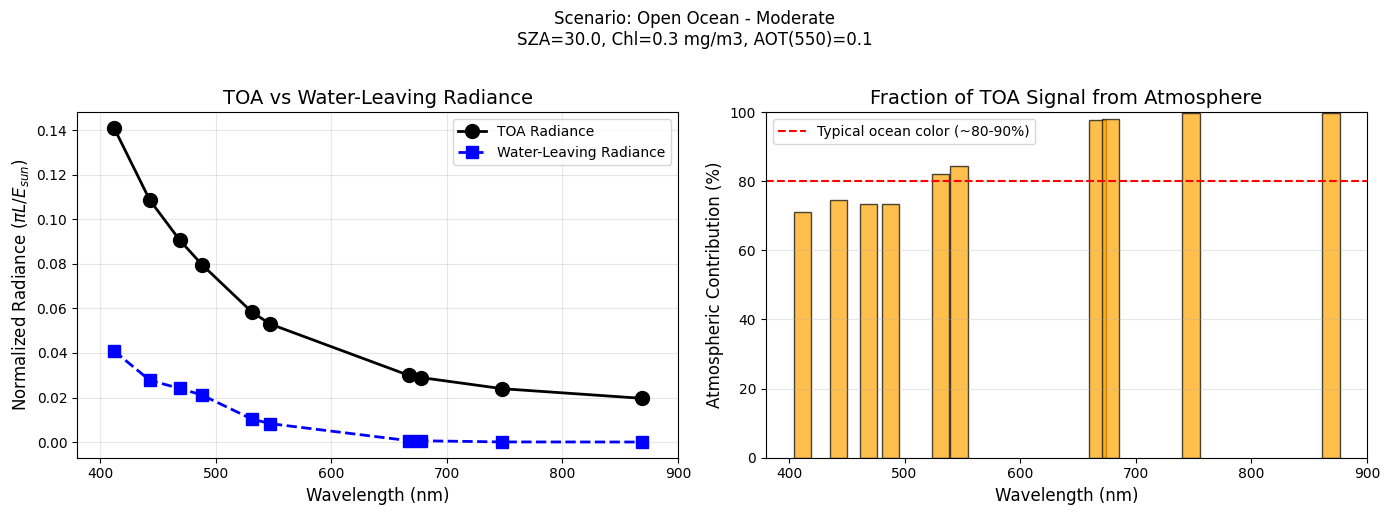

In [11]:
def plot_spectra(toa_radiances, lw_radiances, scenario):
    """Plot TOA and water-leaving radiance spectra."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Common wavelengths
    wavelengths = sorted(set(toa_radiances.keys()) & set(lw_radiances.keys()))
    
    toa_vals = [toa_radiances[wl] for wl in wavelengths]
    lw_vals = [lw_radiances[wl] for wl in wavelengths]
    
    # Left panel: Both spectra
    ax = axes[0]
    ax.plot(wavelengths, toa_vals, 'ko-', markersize=10, linewidth=2, 
            label='TOA Radiance')
    ax.plot(wavelengths, lw_vals, 'bs--', markersize=8, linewidth=2, 
            label='Water-Leaving Radiance')
    ax.set_xlabel('Wavelength (nm)', fontsize=12)
    ax.set_ylabel(r'Normalized Radiance ($\pi L / E_{sun}$)', fontsize=12)
    ax.set_title('TOA vs Water-Leaving Radiance', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(380, 900)
    
    # Right panel: Atmospheric contribution
    ax = axes[1]
    atm_fraction = [100 * (toa - lw) / toa if toa > 0 else 0 
                    for toa, lw in zip(toa_vals, lw_vals)]
    
    ax.bar(wavelengths, atm_fraction, width=15, color='orange', alpha=0.7, 
           edgecolor='black')
    ax.set_xlabel('Wavelength (nm)', fontsize=12)
    ax.set_ylabel('Atmospheric Contribution (%)', fontsize=12)
    ax.set_title('Fraction of TOA Signal from Atmosphere', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(380, 900)
    ax.set_ylim(0, 100)
    
    ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, 
               label='Typical ocean color (~80-90%)')
    ax.legend(fontsize=10)
    
    fig.suptitle(f'Scenario: {scenario.name}\n'
                 f'SZA={scenario.solar_zenith}, Chl={scenario.chlorophyll} mg/m3, '
                 f'AOT(550)={scenario.aot_550}',
                 fontsize=12, y=1.02)
    
    plt.tight_layout()
    return fig


if toa_radiances and lw_radiances:
    plot_spectra(toa_radiances, lw_radiances, scenario)
    plt.show()

## 8. Angular Distribution of TOA Radiance

Let's also look at how TOA radiance varies with viewing angle at a selected wavelength.

In [ ]:
def plot_angular_distribution(toa_results, wavelength=550):
    """Plot TOA radiance angular distribution at a given wavelength."""
    available_wls = list(toa_results.keys())
    closest_wl = min(available_wls, key=lambda x: abs(x - wavelength))
    
    results = toa_results[closest_wl]
    if 'vza_data' not in results:
        print(f"No angular data available for {closest_wl} nm")
        return
    
    vza = results['vza_data']['vza']
    radiance = results['vza_data']['I']
    dolp = results['vza_data']['DoLP']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Radiance vs VZA
    ax = axes[0]
    ax.plot(vza, radiance, 'b-', linewidth=2)
    ax.axvline(x=scenario.view_zenith, color='red', linestyle='--', 
               linewidth=1.5, label=f'Satellite VZA = {scenario.view_zenith}')
    ax.set_xlabel('Viewing Zenith Angle (degrees)', fontsize=12)
    ax.set_ylabel(r'TOA Radiance ($\pi L / E_{sun}$)', fontsize=12)
    ax.set_title(f'TOA Radiance vs Viewing Angle ({closest_wl} nm)', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Polarization vs VZA
    ax = axes[1]
    ax.plot(vza, dolp, 'm-', linewidth=2)
    ax.axvline(x=scenario.view_zenith, color='red', linestyle='--', 
               linewidth=1.5, label=f'Satellite VZA = {scenario.view_zenith}')
    ax.set_xlabel('Viewing Zenith Angle (degrees)', fontsize=12)
    ax.set_ylabel('Degree of Linear Polarization (%)', fontsize=12)
    ax.set_title(f'Polarization vs Viewing Angle ({closest_wl} nm)', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


if toa_results:
    plot_angular_distribution(toa_results, wavelength=547)
    plt.show()

## 9. Create Dataset for Atmospheric Correction

Package the OSOAA outputs into an `OSOAADataset` (from `correct_atmosphere.osoaa`) suitable for the `correct_atmosphere` package.

In [ ]:
# Create dataset (OSOAADataset, create_dataset imported from correct_atmosphere.osoaa)
if toa_radiances and lw_radiances:
    dataset = create_dataset(
        toa_radiances, lw_radiances, scenario,
        radiance_components=radiance_components,
    )
    dataset.summary()

## 10. Save Dataset for Later Use

Let's save the simulation results so they can be loaded later without re-running OSOAA.

In [ ]:
# Save the dataset (save_dataset / load_dataset imported from correct_atmosphere.osoaa)
if 'dataset' in dir():
    output_path = Path('.') / 'osoaa_toa_dataset.json'
    save_dataset(dataset, output_path)
    print(f"Dataset saved to: {output_path}")

## 11. Summary: Output Data Dictionary

Here's a summary of what OSOAA provides for atmospheric correction testing:

In [14]:
if 'dataset' in dir():
    print("OSOAA Output Summary")
    print("=" * 70)
    print(f"\n{'Wavelength (nm)':<15} {'TOA Refl':>12} {'True Lw Refl':>14} {'Atm Frac (%)':>14}")
    print("-" * 70)
    
    for i, wl in enumerate(dataset.wavelengths):
        toa = dataset.toa_reflectance[i]
        lw = dataset.true_rho_w[i]
        atm_frac = 100 * (toa - lw) / toa if toa > 0 else 0
        print(f"{wl:>8.0f}        {toa:>12.6f} {lw:>14.6f} {atm_frac:>14.1f}")
    
    print("-" * 70)
    print("\nNote: All reflectances are normalized (pi*L/E_sun)")
    print("\nThis data can now be used to test atmospheric correction algorithms.")
    print("The goal is to recover 'True Lw Refl' from 'TOA Refl'.")

OSOAA Output Summary

Wavelength (nm)     TOA Refl   True Lw Refl   Atm Frac (%)
----------------------------------------------------------------------
     412            0.141047       0.040930           71.0
     443            0.108579       0.027704           74.5
     469            0.090556       0.024073           73.4
     488            0.079708       0.021156           73.5
     531            0.058507       0.010397           82.2
     547            0.053021       0.008299           84.3
     667            0.029964       0.000654           97.8
     678            0.028944       0.000593           98.0
     748            0.023966       0.000079           99.7
     869            0.019637       0.000037           99.8
----------------------------------------------------------------------

Note: All reflectances are normalized (pi*L/E_sun)

This data can now be used to test atmospheric correction algorithms.
The goal is to recover 'True Lw Refl' from 'TOA Refl'.


## 12. Multiple Scenarios (Optional)

Generate TOA data for multiple scenarios to build a more comprehensive test dataset.

In [ ]:
# Define additional test scenarios
test_scenarios = [
    SimulationScenario(
        name="Clear Water - Low Aerosol",
        solar_zenith=30.0,
        view_zenith=15.0,
        relative_azimuth=90.0,
        chlorophyll=0.05,
        aot_550=0.05,
        wind_speed=3.0,
    ),
    SimulationScenario(
        name="Moderate Chl - Moderate Aerosol",
        solar_zenith=45.0,
        view_zenith=20.0,
        relative_azimuth=135.0,
        chlorophyll=0.5,
        aot_550=0.15,
        wind_speed=7.0,
    ),
    SimulationScenario(
        name="High Chl - High Aerosol",
        solar_zenith=50.0,
        view_zenith=30.0,
        relative_azimuth=45.0,
        chlorophyll=2.0,
        aot_550=0.25,
        wind_speed=10.0,
    ),
]

print("Additional test scenarios defined:")
for i, s in enumerate(test_scenarios, 1):
    print(f"\n{i}. {s}")

print("\n(Run the simulation loop above with each scenario to generate data)")

## 13. Cleanup

Remove temporary files created during simulations.

In [ ]:
# Set to True to clean up temporary OSOAA files
cleanup = False

if cleanup and 'sim' in dir():
    print(f"Cleaning up: {sim.work_dir}")
    sim.cleanup()
    print("Done.")
else:
    if 'sim' in dir():
        print(f"Temporary files preserved in: {sim.work_dir}")
        print(f"Output files: {sim.work_dir / 'Standard_outputs'}")

## Next Steps

With the OSOAA-generated TOA radiances, you can now:

1. **Test atmospheric correction**: Apply the `correct_atmosphere` package to the TOA data
2. **Validate results**: Compare recovered water-leaving radiance with OSOAA's "truth"
3. **Sensitivity studies**: Vary atmospheric/oceanic parameters and assess correction accuracy
4. **Error analysis**: Quantify uncertainties in the atmospheric correction process

### Key Equations

The atmospheric correction removes path radiance to recover water-leaving radiance:

$$L_t = L_{path} + t \cdot L_w$$

Where:
- $L_t$ = TOA radiance (from OSOAA at Level 1)
- $L_{path}$ = Atmospheric path radiance (Rayleigh + aerosol + glint)
- $t$ = Diffuse transmittance
- $L_w$ = Water-leaving radiance (from OSOAA at Level 4)

### References

- Mobley et al. (2016). NASA TM-2016-217551 - Atmospheric Correction Algorithm
- Chami et al. (2015). OSOAA model description, Opt. Express 23, 27829
- Gordon & Wang (1994). SeaWiFS atmospheric correction, Appl. Opt. 33, 443